2026-09-01 10:08:50.384 | INFO     | __main__:router_node:49 - router node start...
2026-09-01 10:08:51.278 | INFO     | __main__:router_node:56 - router result is: {'topic': '荷花', 'mode': 'poem'}
2026-09-01 10:08:51.280 | INFO     | __main__:router:60 - router function start...
2026-09-01 10:08:51.281 | INFO     | __main__:router:62 - router poem start...
2026-09-01 10:08:51.283 | INFO     | __main__:node_poem:71 - node_poem node start...


{'username': 'xiaowang', 'user_input': '荷花的诗', 'output': AIMessage(content='《荷花》\n翠盖摇风香满衣，凌波素影浴清辉。\n苦心莫问因谁卷，自守莲房待月归。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 18, 'total_tokens': 52, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 18}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '2b1f1e53-8f32-4a82-b35f-5daab1a932f0', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a05ab9-f454-73c1-b64b-97d283c22bcf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 34, 'total_tokens': 52, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})}


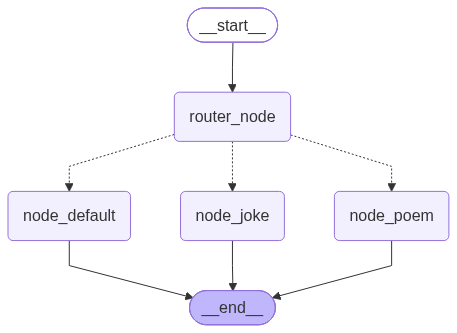

In [21]:

from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.checkpoint.memory import InMemorySaver
import time
from operator import add
from langchain_core.messages import ToolMessage, SystemMessage
from random import randint

from langchain_core.runnables import RunnableConfig
from langgraph.cache.memory import InMemoryCache
from langgraph.errors import GraphRecursionError
from langgraph.graph import MessagesState

from multiprocessing import resource_tracker

from langgraph.graph import StateGraph, START, END, MessagesState, MessageGraph
from typing import TypedDict, Literal, Sequence, Annotated
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from langchain.tools import tool
from langgraph.managed.is_last_step import RemainingSteps
from loguru import logger
from langgraph.types import Send, Command, CachePolicy
from langchain.messages import HumanMessage, AIMessage, SystemMessage
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

class OverAllState(TypedDict):
    username: str
    user_input: str
    output: str

class StructureOutputState(TypedDict):
    topic: Annotated[str, "主题"]
    mode: Annotated[Literal["poem","joke","default"],"模式"]

model_with_structure = model.with_structured_output(schema=StructureOutputState)

def router_node(state:OverAllState)->StructureOutputState:
    logger.info("router node start...")
    user_input = state["user_input"]
    res = model_with_structure.invoke(
        [
            HumanMessage(user_input),
        ]
    )
    logger.info("router result is: {}",res)
    return res

def router(state:StructureOutputState)->Literal["node_poem","node_joke", "node_default"]:
    logger.info("router function start...")
    if state["mode"] == "poem":
        logger.info("router poem start...")
        return "node_poem"
    elif state["mode"] == "joke":
        logger.info("router joke start...")
        return "node_joke"
    logger.info("router function default...")
    return "node_default"

def node_poem(state:StructureOutputState)->OverAllState:
    logger.info("node_poem node start...")
    topic=state["topic"]
    poem=model.invoke(
        [
            HumanMessage(f"写一首关于{topic}的七言绝句，只写诗句部分").content,
        ]
    )
    return {
        "output": poem,
    }

def node_joke(state:StructureOutputState)->OverAllState:
    logger.info("node_joke node start...")
    topic=state["topic"]
    joke=model.invoke(
        [
            HumanMessage(f"写一首关于{topic}的笑话，只写笑话部分").content,
        ]
    )
    return {
        "output": joke,
    }


def node_default(state:StructureOutputState)->OverAllState:
    logger.info("node_default node start...")
    return {
        "output": "default node..................."
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("router_node", router_node)
builder.add_node("node_default", node_default)

builder.add_edge(START, "router_node")
builder.add_conditional_edges("router_node", router, path_map=["node_poem", "node_joke","node_default"])
builder.add_edge("node_poem",END)
builder.add_edge("node_joke",END)
builder.add_edge("node_default",END)

checkpointer = InMemorySaver()
config={
    "configurable":{
        "thread_id": "123"
    }
}
graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({
    "username": "xiaowang",
    "user_input": "荷花的诗",
    },config=config
)
print(res)
display(graph)



In [22]:
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

[StateSnapshot(values={'username': 'xiaowang', 'user_input': '荷花的诗', 'output': AIMessage(content='《荷花》\n翠盖摇风香满衣，凌波素影浴清辉。\n苦心莫问因谁卷，自守莲房待月归。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 18, 'total_tokens': 52, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 18}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '2b1f1e53-8f32-4a82-b35f-5daab1a932f0', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a05ab9-f454-73c1-b64b-97d283c22bcf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 34, 'total_tokens': 52, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), 'topic': '荷花', 'mode': 'poem'}

In [23]:
before_router_checkpoint = next(h for h in history_checkpoints if h.next ==("router_node",))
print(before_router_checkpoint)

StateSnapshot(values={'username': 'xiaowang', 'user_input': '荷花的诗'}, next=('router_node',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5aa1-2cfd-6a6b-8000-be05660209c3'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-01T02:08:50.383093+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5aa1-2cf9-6511-bfff-4dc443789815'}}, tasks=(PregelTask(id='d47978ac-1591-d680-1f4e-f5e53e9e8fa6', name='router_node', path=('__pregel_pull', 'router_node'), error=None, interrupts=(), state=None, result={'topic': '荷花', 'mode': 'poem'}),), interrupts=())


In [26]:
change_input = graph.update_state(
    config = before_router_checkpoint.config,
    values={"user_input":"帮我写一个荷花的小型笑话"},
    as_node=START
)
print(change_input)
graph.get_state(change_input)

{'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5aac-c11e-6583-8001-f08037e34d62'}}


StateSnapshot(values={'username': 'xiaowang', 'user_input': '帮我写一个荷花的小型笑话'}, next=('router_node',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5aac-c11e-6583-8001-f08037e34d62'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-09-01T02:14:01.194385+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5aa1-2cfd-6a6b-8000-be05660209c3'}}, tasks=(PregelTask(id='ceea4d58-916d-2186-711c-463d2abb71cc', name='router_node', path=('__pregel_pull', 'router_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [27]:
res = graph.invoke(None, config=change_input)
print(res)

2026-09-01 10:15:20.410 | INFO     | __main__:router_node:49 - router node start...
2026-09-01 10:15:21.586 | INFO     | __main__:router_node:56 - router result is: {'topic': '荷花', 'mode': 'joke'}
2026-09-01 10:15:21.588 | INFO     | __main__:router:60 - router function start...
2026-09-01 10:15:21.589 | INFO     | __main__:router:65 - router joke start...
2026-09-01 10:15:21.594 | INFO     | __main__:node_joke:83 - node_joke node start...


{'username': 'xiaowang', 'user_input': '帮我写一个荷花的小型笑话', 'output': AIMessage(content='好的，这是一则关于荷花的笑话：\n\n---\n\n池塘边，一只小青蛙对着荷花大喊：“喂！你装什么清高？天天站着不动，也不说话！”\n\n荷花轻轻摇了摇花瓣，不理它。\n\n小青蛙更来劲了：“你看我，蹦蹦跳跳，多自由！你再看看你，根扎在泥里，动都动不了！”\n\n这时，荷花终于开口了，声音又柔又慢：\n\n“你说得对。可是……我虽然动不了，但我‘出淤泥而不染’；你呢？你整天‘呱呱’叫，是不是‘近墨者黑’了？”\n\n小青蛙一愣：“啥意思？”\n\n荷花微微一笑：“意思就是——你天天泡在这泥水里，怎么没见你染出点文化来？还在这儿‘呱呱’半天，一句诗都憋不出来。”\n\n---\n\n（完）', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 177, 'prompt_tokens': 15, 'total_tokens': 192, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 15}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': 'c25e09ae-67bd-44b4-ab8c-5144887347e7', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a05abf-e8fd

In [29]:
skip_router_config = graph.update_state(
    config=before_router_checkpoint.config,
    values ={"topic":"彩色猴","mode":"笑话"},
    as_node="router_node"
)
print(skip_router_config)
print(graph.get_state(skip_router_config))

2026-09-01 10:20:47.408 | INFO     | __main__:router:60 - router function start...
2026-09-01 10:20:47.410 | INFO     | __main__:router:67 - router function default...


{'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5abb-e31e-6ddf-8001-9d102e8b9531'}}
StateSnapshot(values={'username': 'xiaowang', 'user_input': '荷花的诗', 'topic': '彩色猴', 'mode': '笑话'}, next=('node_default',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5abb-e31e-6ddf-8001-9d102e8b9531'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-09-01T02:20:47.412953+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5aa1-2cfd-6a6b-8000-be05660209c3'}}, tasks=(PregelTask(id='933c81d0-4f6b-71b3-d007-bcf73b7293a5', name='node_default', path=('__pregel_pull', 'node_default'), error=None, interrupts=(), state=None, result=None),), interrupts=())
